In [2]:
import os
from kaggle_secrets import UserSecretsClient

secret_label = "WANDB_API_KEY"
secret_value = UserSecretsClient().get_secret(secret_label)

import wandb
wandb.login(key=secret_value)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: snrupendra (snrupendra-sardar-vallabhbhai-national-institute-of-tech) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
dataset_path = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'

classes = sorted(os.listdir(dataset_path))
print(f"Total classes: {len(classes)}")
print("\nFirst 10 classes:")
for c in classes[:10]:
    print(f"\t{c}")

Total classes: 38

First 10 classes:
	Apple___Apple_scab
	Apple___Black_rot
	Apple___Cedar_apple_rust
	Apple___healthy
	Blueberry___healthy
	Cherry_(including_sour)___Powdery_mildew
	Cherry_(including_sour)___healthy
	Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
	Corn_(maize)___Common_rust_
	Corn_(maize)___Northern_Leaf_Blight


## EDA

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
import numpy as np

dataset_path = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'
classes = sorted(os.listdir(dataset_path))

# Count images per class
class_counts = {}
total_images = 0

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(cls_path))
    class_counts[cls] = count
    total_images += count

print(f"Total images: {total_images}")
print(f"Total classes: {len(classes)}")
print(f"Average images per class: {total_images // len(classes)}")
print(f"Min images in a class : {min(class_counts.values())} ({min(class_counts, key=class_counts.get)})")
print(f"Max images in a class: {max(class_counts.values())} ({max(class_counts, key=class_counts.get)})")

Total images: 54305
Total classes: 38
Average images per class: 1429
Min images in a class : 152 (Potato___healthy)
Max images in a class: 5507 (Orange___Haunglongbing_(Citrus_greening))


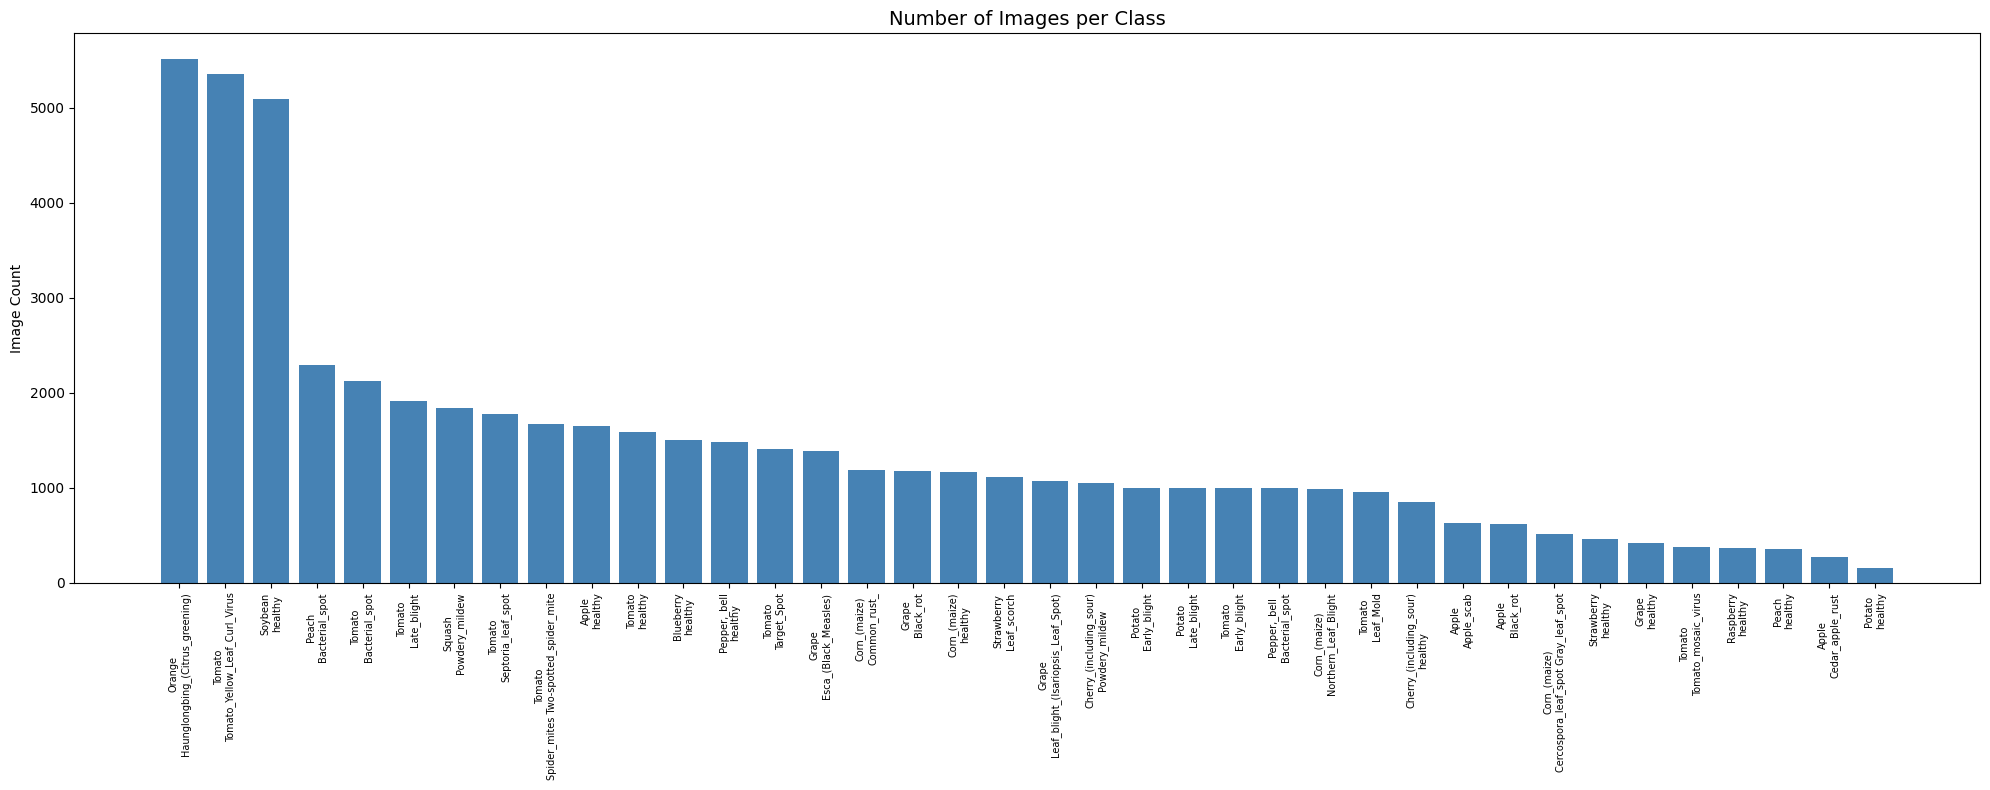

In [6]:
plt.figure(figsize=(20, 8))
sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

bars = plt.bar(range(len(sorted_counts)), list(sorted_counts.values()), color='steelblue')
plt.xticks(range(len(sorted_counts)),
          [c.replace('___', '\n') for c in sorted_counts.keys()],
          rotation=90, fontsize=7)
plt.title('Number of Images per Class', fontsize=14)
plt.ylabel('Image Count')
plt.tight_layout()
plt.show()

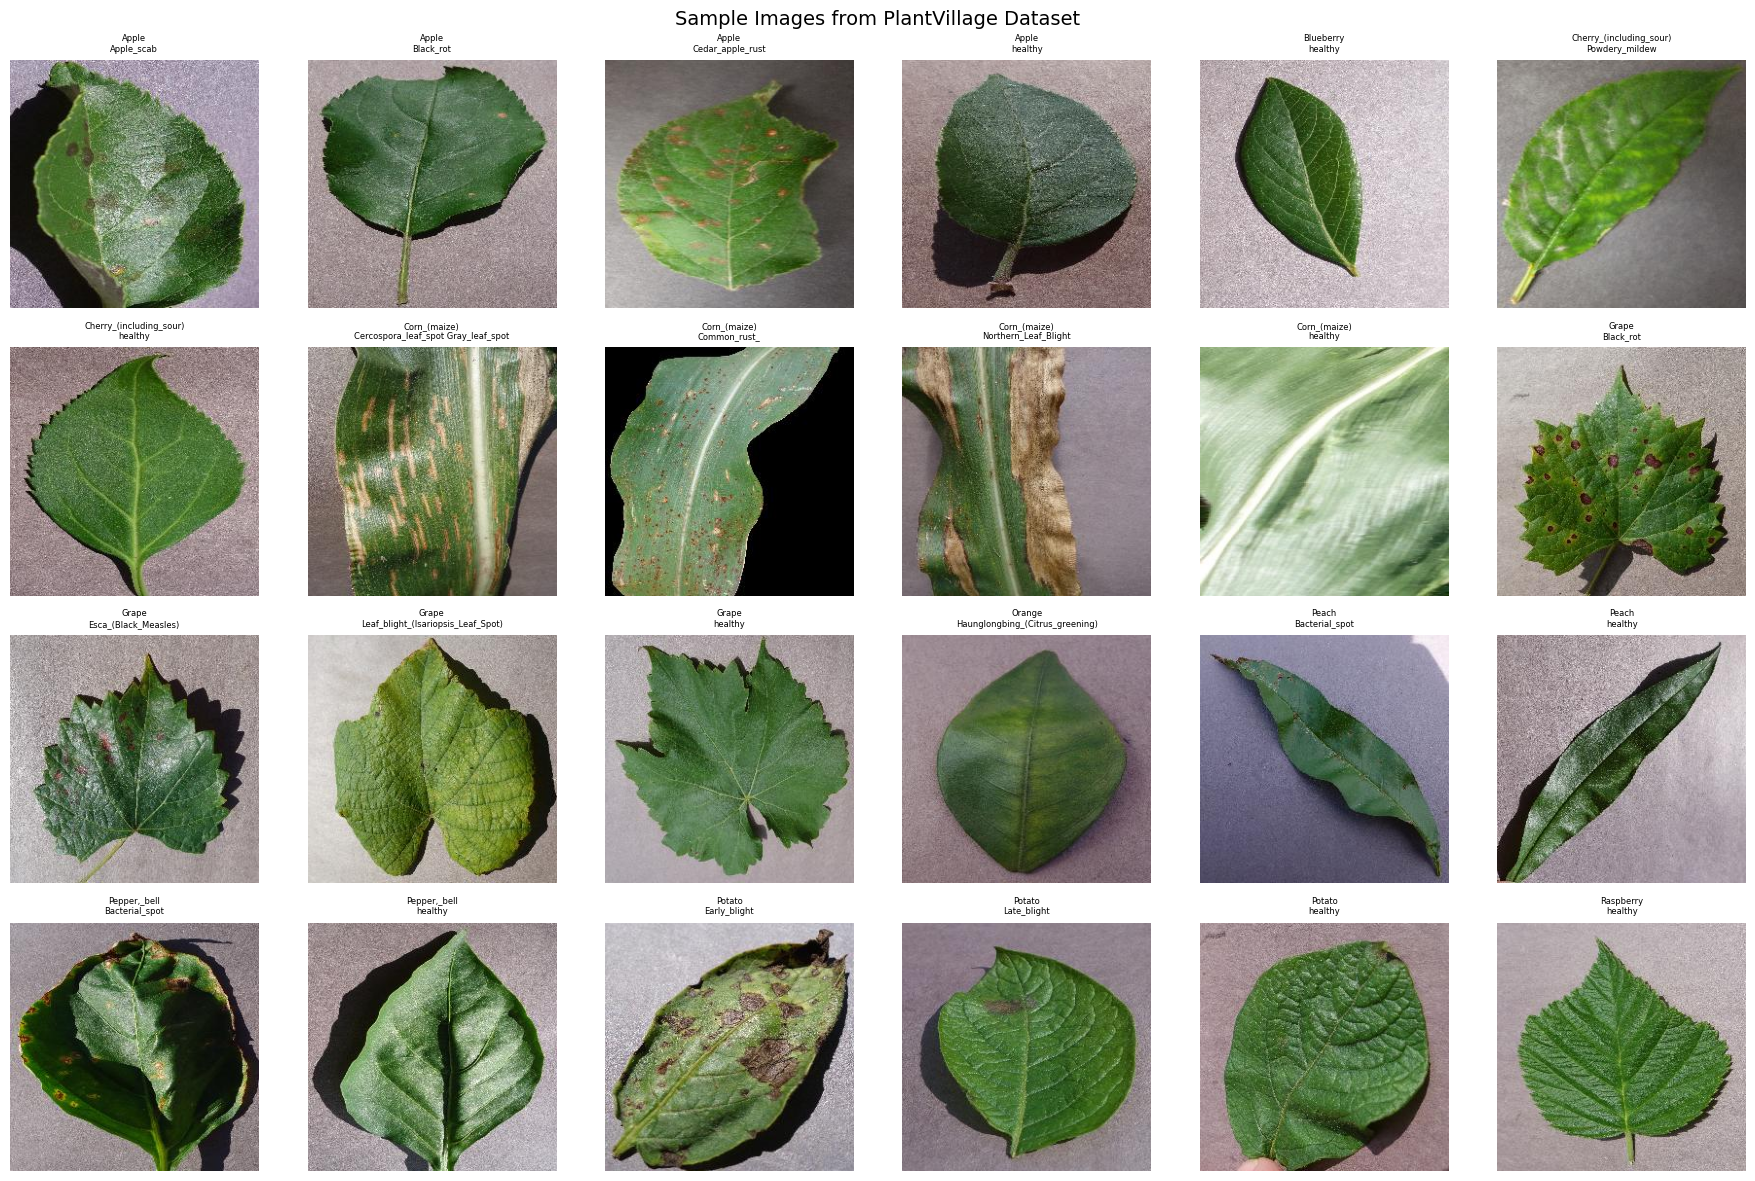

In [8]:
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

sample_classes = classes[:24]

for idx, cls in enumerate(sample_classes):
    cls_path = os.path.join(dataset_path, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    
    axes[idx].imshow(img)
    axes[idx].set_title(cls.replace('___', '\n'), fontsize=6)
    axes[idx].axis('off')

plt.suptitle('Sample Images from PlantVillage Dataset', fontsize=14)
plt.tight_layout()
plt.show()

**Here the images are taken against a plain background. Leaves are photographed in isolation, not in field. This makes the classification easier than real-world deployment. This is Good for getting high accuracy, but limitation when deployed in real-world conditions (field photos with soil, sunlight, overlapping leaves in the background).**